# Amplitude Loss Experiment

Runs only the non-baseline amplitude-loss experiment. The intensity-loss baseline is in the dense random notebook.


device: cuda
image shape: (1, 1, 32, 32) phase img size: (1, 32, 32) signal shape: (1, 1, 32, 32) n: 1024
run: method=GD, model=deepinv_random, loss=amplitude, init=spectral, alpha=4.0, noise=0.0
    shapes: x_true=(1, 1, 32, 32), x_init=(1, 1, 32, 32), y=(1, 4096)
run: method=Accelerated GD, model=deepinv_random, loss=amplitude, init=spectral, alpha=4.0, noise=0.0
    shapes: x_true=(1, 1, 32, 32), x_init=(1, 1, 32, 32), y=(1, 4096)
run: method=Adam, model=deepinv_random, loss=amplitude, init=spectral, alpha=4.0, noise=0.0
    shapes: x_true=(1, 1, 32, 32), x_init=(1, 1, 32, 32), y=(1, 4096)
run: method=NCG, model=deepinv_random, loss=amplitude, init=spectral, alpha=4.0, noise=0.0
    shapes: x_true=(1, 1, 32, 32), x_init=(1, 1, 32, 32), y=(1, 4096)
run: method=L-BFGS, model=deepinv_random, loss=amplitude, init=spectral, alpha=4.0, noise=0.0
    shapes: x_true=(1, 1, 32, 32), x_init=(1, 1, 32, 32), y=(1, 4096)


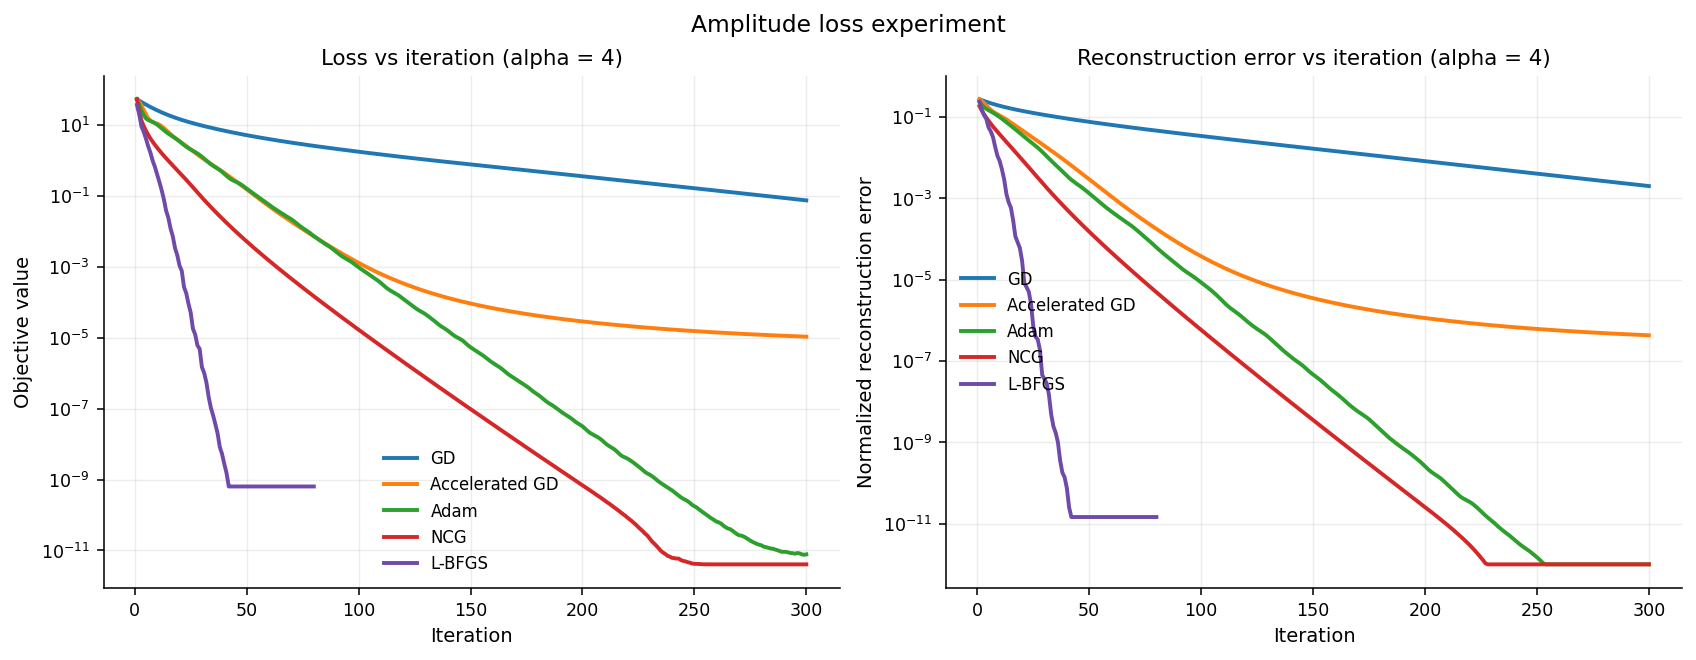

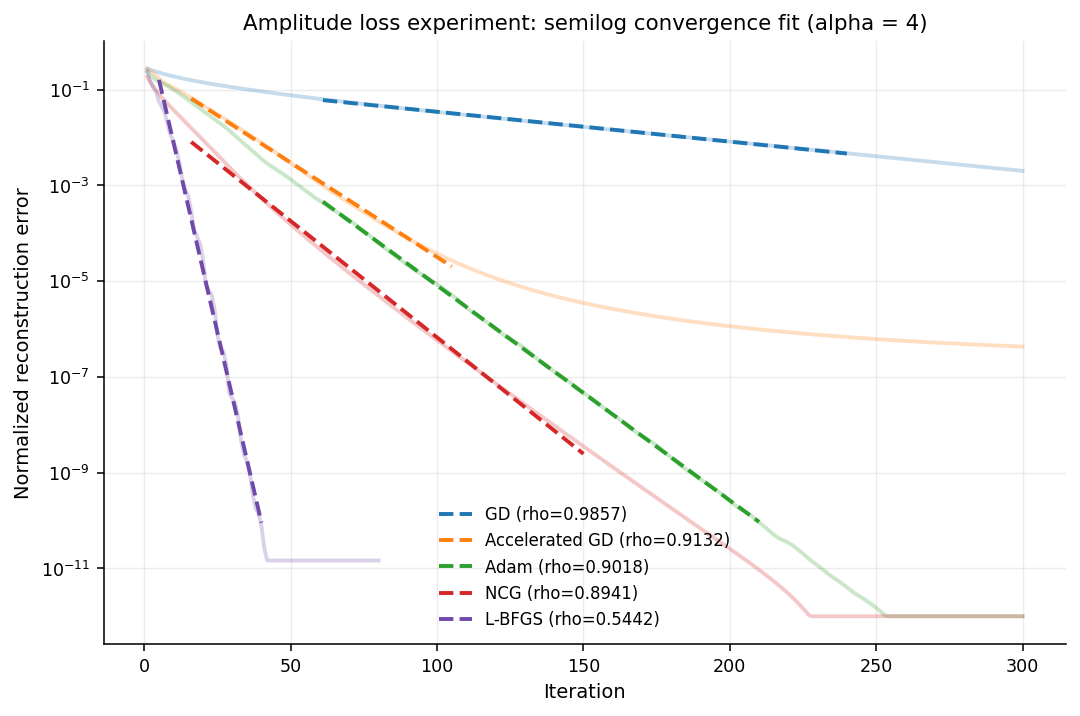

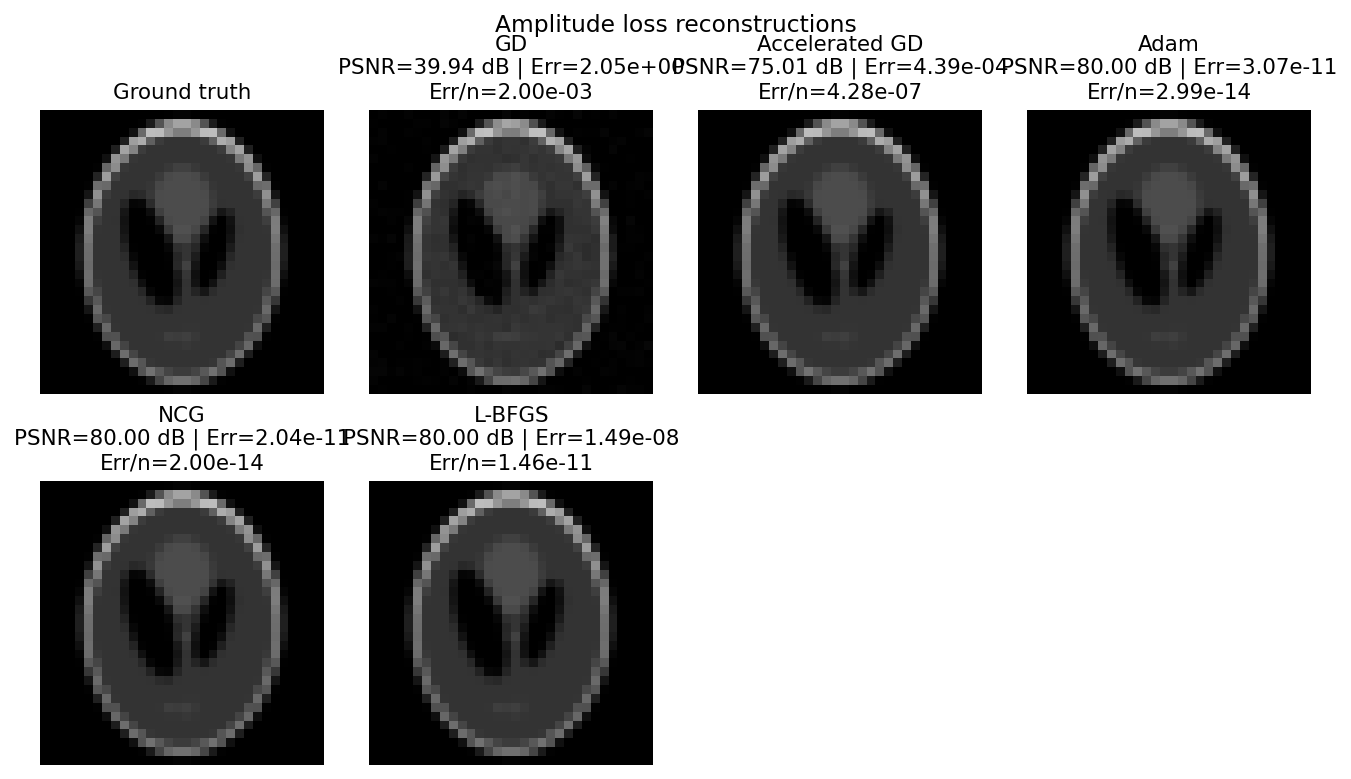

,label,method,psnr_db,final_reconstruction_error,normalized_final_reconstruction_error
0,GD,GD,39.941959,2.047967e+00,1.999967e-03
1,Accelerated GD,Accelerated GD,75.011742,4.387798e-04,4.284959e-07
2,Adam,Adam,80.000000,3.066722e-11,2.994846e-14
3,NCG,NCG,80.000000,2.044379e-11,1.996463e-14
4,L-BFGS,L-BFGS,79.999702,1.492500e-08,1.457520e-11


,method,model,loss,initialization,alpha,noise_level,final_loss,final_reconstruction_error,psnr_db,runtime_seconds,iterations,success
0,GD,deepinv_random,amplitude,spectral,4.0,0.0,7.507233e-02,2.047967e+00,39.941959,3.432676,300,True
1,Accelerated GD,deepinv_random,amplitude,spectral,4.0,0.0,1.072269e-05,4.387798e-04,75.011742,3.913778,300,True
2,Adam,deepinv_random,amplitude,spectral,4.0,0.0,7.760172e-12,3.066722e-11,80.000000,4.100132,300,True
3,NCG,deepinv_random,amplitude,spectral,4.0,0.0,4.062235e-12,2.044379e-11,80.000000,8.805857,300,True
4,L-BFGS,deepinv_random,amplitude,spectral,4.0,0.0,6.390956e-10,1.492500e-08,79.999702,2.178958,80,True


In [6]:
from pathlib import Path
import sys

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "report_experiments_split").exists():
        sys.path.insert(0, str(candidate))
        break

from report_experiments_split import config, problem, metrics, runners, plotting, common, experiment_configs
import importlib
importlib.reload(config)
importlib.reload(problem)
importlib.reload(metrics)
importlib.reload(runners)
importlib.reload(plotting)
importlib.reload(common)
importlib.reload(experiment_configs)
from report_experiments_split.experiments import loss_comparison

importlib.reload(loss_comparison)

outputs = loss_comparison.run()
summary = outputs.get('summary')
summary
